<a href="https://colab.research.google.com/github/NatGli/CSC-481-02-HW3/blob/main/Week3Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nathaniel Glidden, Python Notebook HW 3, 2/12/*25*



What is Linear Regression?

Linear regression analysis in short is used to predict the value of a variable based on another variable. Prediction is the dependent variable. The variable using to predict is called the independent variable. Yi = B0 +B1 * Xi

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("student_scores.csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [ ]:
df.shape

(25, 2)

In [ ]:
X = df.drop("Scores", axis=1)
y = df["Scores"]

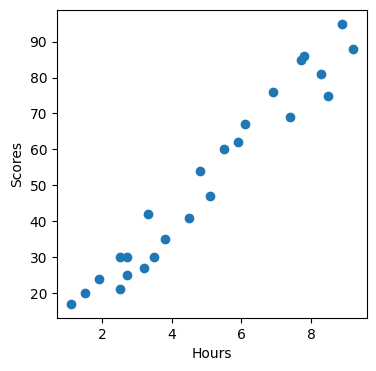

In [ ]:
plt.figure(figsize=(4,4))

plt.scatter(X,y)
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.grid = True
plt.show()

In [ ]:
from sklearn import datasets, model_selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 23)



In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
alpha = model.intercept_
beta = model.coef_
print("alpha", "{:.2f}".format(alpha))
print("beta", beta)
print(f"y = {alpha} + {beta} X")

alpha -0.34
beta [10.28085594]
y = -0.33798242262133016 + [10.28085594] X


In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

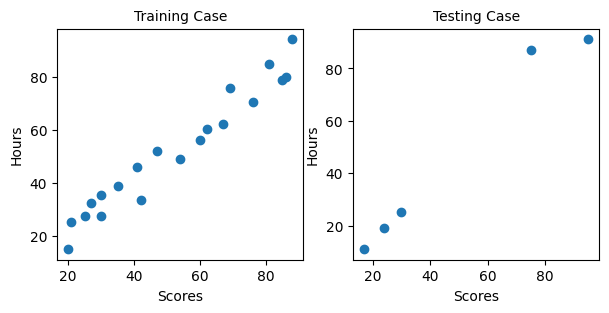

In [ ]:
plt.figure(figsize=(7,3))

#subplot 1
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train)
plt.title("Training Case", fontsize = 10)
plt.xlabel("Scores")
plt.ylabel("Hours")

#subplot 2
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test)
plt.title("Testing Case", fontsize = 10)
plt.xlabel("Scores")
plt.ylabel("Hours")


plt.show()

In [ ]:
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train,y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test,y_pred_test)

#create a df of the results
performance_df = pd.DataFrame({
    "Metric" : ["MSE", "MAE", "MSE", "MAE"],
    "DataType":["train", "train", "test", "test"],
    "Values": [mse_train, mae_train, mse_test, mae_test]
})
performance_df.T

,0,1,2,3
Metric,MSE,MAE,MSE,MAE
DataType,train,train,test,test
Values,26.118428,4.871914,48.168143,6.271379
